<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Agentic_AI_Driving_Intelligent_Industrial_Automation_Autonomous%2C_Decision_Making_Multi_Agent_Workflows_for_Complex_Industrial_Environments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import sys
!{sys.executable} -m pip install kaggle

To use the Kaggle API, you need to set up your Kaggle credentials. Follow these steps:

1.  Go to [Kaggle](https://www.kaggle.com/).
2.  Click on your profile picture in the top right corner and select "My Account".
3.  Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file.
4.  Open the `kaggle.json` file and copy its content (your username and key).
5.  In Colab, go to the left panel, click on the "🔑" icon (Secrets), and add two new secrets:
    *   Name: `KAGGLE_USERNAME`, Value: Your Kaggle username from `kaggle.json`.
    *   Name: `KAGGLE_KEY`, Value: Your Kaggle API key from `kaggle.json`.

After setting these secrets, run the following cell to configure the Kaggle API.

In [16]:
from kaggle.api.kaggle_api_extended import KaggleApi
from google.colab import userdata

# Configure Kaggle API with secrets
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

api = KaggleApi()
api.authenticate()

Now, let's search for datasets related to industrial automation, smart factories, or predictive maintenance to find a suitable one.

In [19]:
search_queries = [
    "industrial automation data",
    "factory sensor data",
    "predictive maintenance dataset",
    "smart manufacturing data",
    "iot industrial data"
]

for query in search_queries:
    print(f"\nSearching for datasets related to: '{query}'")
    # Changed 'relevance' to 'hottest' as 'relevance' is not a valid sort_by option.
    datasets = api.dataset_list(search=query, sort_by='hottest', file_type='csv')
    if datasets:
        for dataset in datasets[:5]: # Display top 5 relevant datasets for each query
            print(f"  - {dataset.ref} (Title: {dataset.title})")
    else:
        print("  No datasets found.")


Searching for datasets related to: 'industrial automation data'
  - kennedywanakacha/industrial-robotics-and-automation-dataset (Title: Industrial Robotics and Automation Dataset)
  - rauffauzanrambe/industrial-smart-factory-automation-dataset-2026 (Title: Industrial Smart Factory Automation Dataset 2026)
  - rauffauzanrambe/worldwide-robotic-process-automation-database-2026 (Title: Worldwide Robotic Process Automation Database 2026)
  - arashnic/sensor-fault-detection-data (Title: Sensor Fault Detection Data)
  - dhrubangtalukdar/abb-india-stock-data-2002-2025 (Title: ABB India Stock Data (Latest))

Searching for datasets related to: 'factory sensor data'
  - rauffauzanrambe/industrial-smart-factory-automation-dataset-2026 (Title: Industrial Smart Factory Automation Dataset 2026)
  - ziya07/smart-manufacturing-maintenance-dataset (Title: Smart Manufacturing Maintenance Dataset)
  - sydsxdiq/industrial-iot-dataset-vibration-gas-environment (Title: Industrial IoT Multi-Axis Vibration D

In [20]:
import os
from zipfile import ZipFile

dataset_ref = 'stephanmatzka/predictive-maintenance-dataset-ai4i-2020'
dataset_name = dataset_ref.split('/')[-1]

# Create a directory for the dataset if it doesn't exist
dataset_path = f'./{dataset_name}'
os.makedirs(dataset_path, exist_ok=True)

print(f"Downloading dataset: {dataset_ref} to {dataset_path}")
api.dataset_download_files(dataset_ref, path=dataset_path, unzip=False)

# Unzip the downloaded file
for item in os.listdir(dataset_path):
    if item.endswith('.zip'):
        file_path = os.path.join(dataset_path, item)
        with ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_path)
        print(f"Unzipped {item}")
        os.remove(file_path) # Remove the zip file after extraction

print(f"\nContents of '{dataset_path}':")
print(os.listdir(dataset_path))

Dataset URL: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
Unzipped predictive-maintenance-dataset-ai4i-2020.zip

Contents of './predictive-maintenance-dataset-ai4i-2020':
['ai4i2020.csv']


In [21]:
import pandas as pd

# Define the path to the CSV file
csv_file_path = './predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("Dataset loaded successfully!")

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nShape of the dataset (rows, columns):")
print(df.shape)

print("\nInformation about the dataset columns:")
print(df.info())

Dataset loaded successfully!

First 5 rows of the dataset:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF

In [22]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


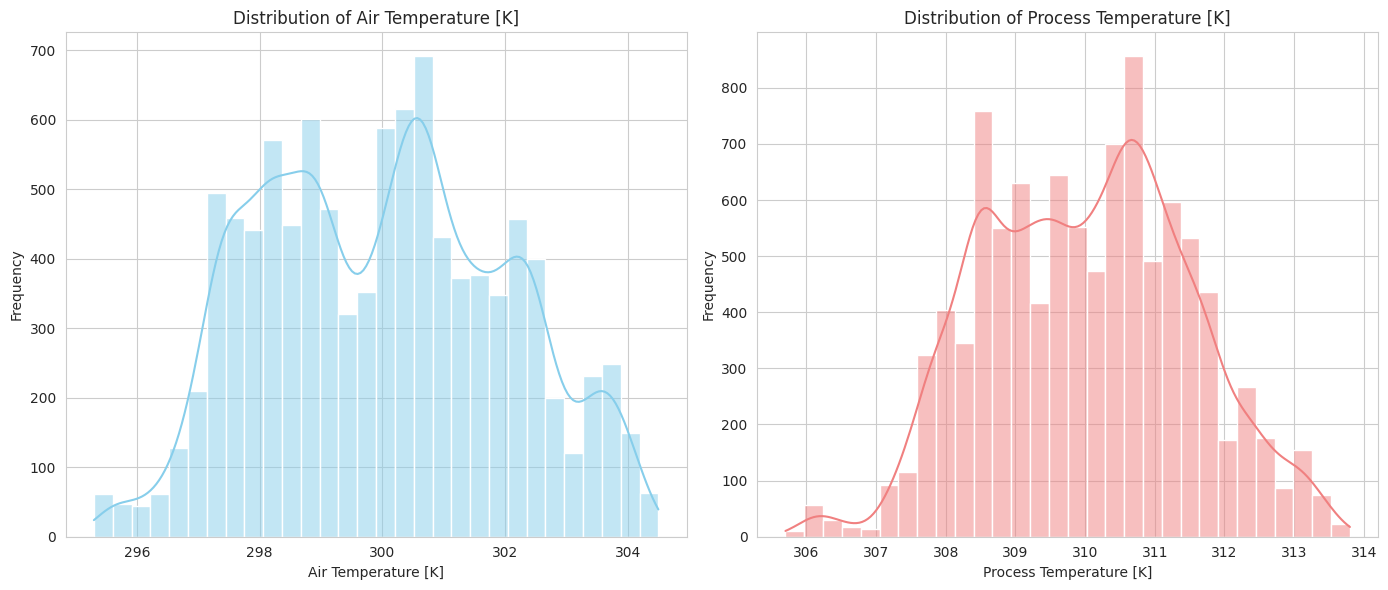

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots for the temperature distributions
plt.figure(figsize=(14, 6))

# Subplot 1: Air temperature distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Air temperature [K]'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Air Temperature [K]')
plt.xlabel('Air Temperature [K]')
plt.ylabel('Frequency')

# Subplot 2: Process temperature distribution
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['Process temperature [K]'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Process Temperature [K]')
plt.xlabel('Process Temperature [K]')
plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

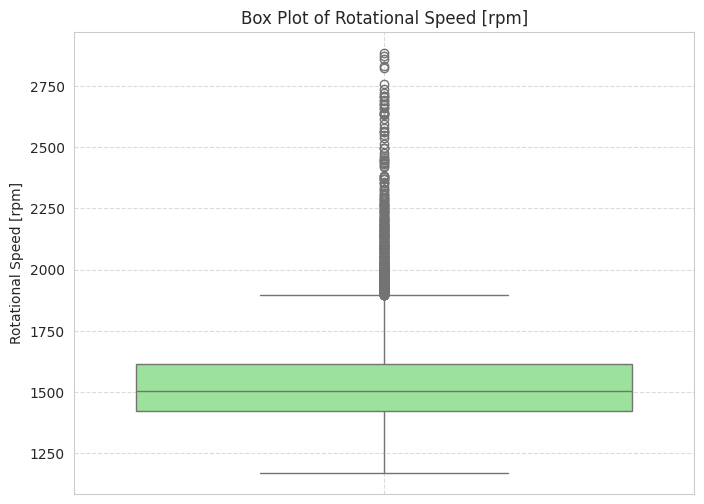

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Rotational speed [rpm]'], color='lightgreen')
plt.title('Box Plot of Rotational Speed [rpm]')
plt.ylabel('Rotational Speed [rpm]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

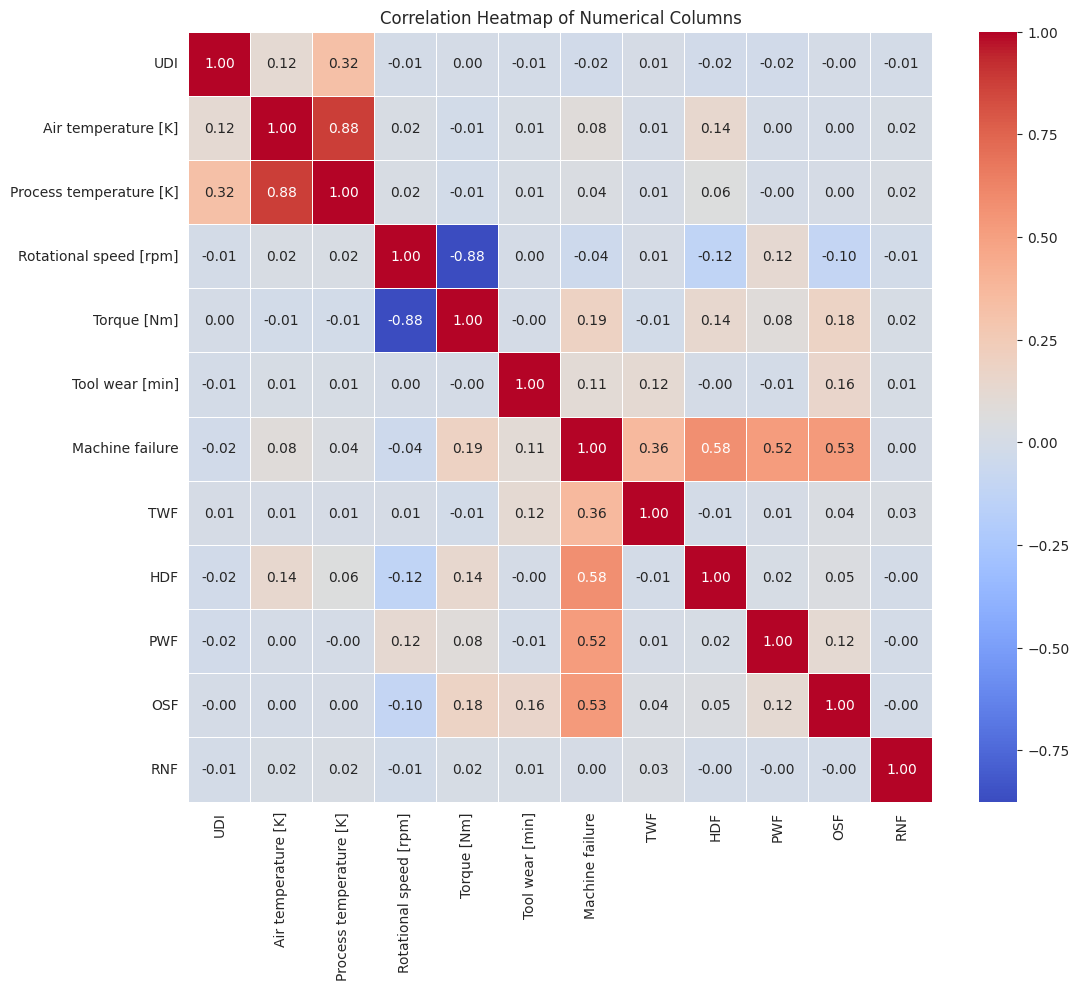

In [25]:
# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

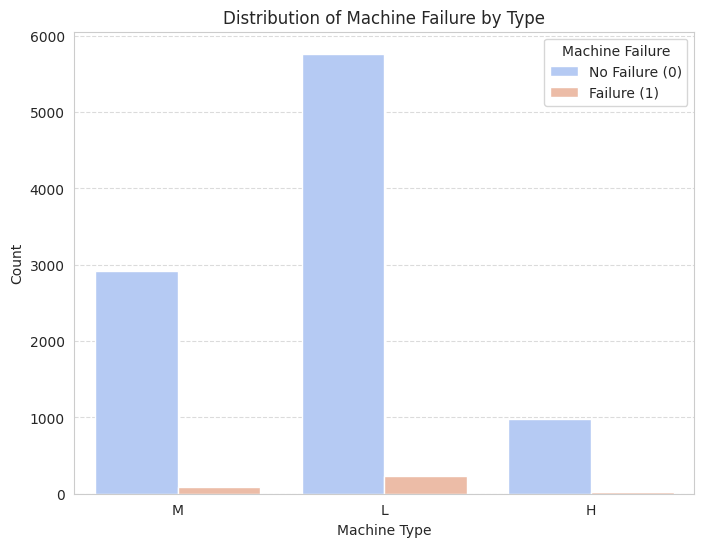

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Type', hue='Machine failure', palette='coolwarm')
plt.title('Distribution of Machine Failure by Type')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Machine Failure', labels=['No Failure (0)', 'Failure (1)'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
failure_rate_by_type = df.groupby('Type')['Machine failure'].mean() * 100
display(failure_rate_by_type.to_frame(name='Failure Rate (%)'))

,Failure Rate (%)
Type,
H,2.093719
L,3.916667
M,2.769436


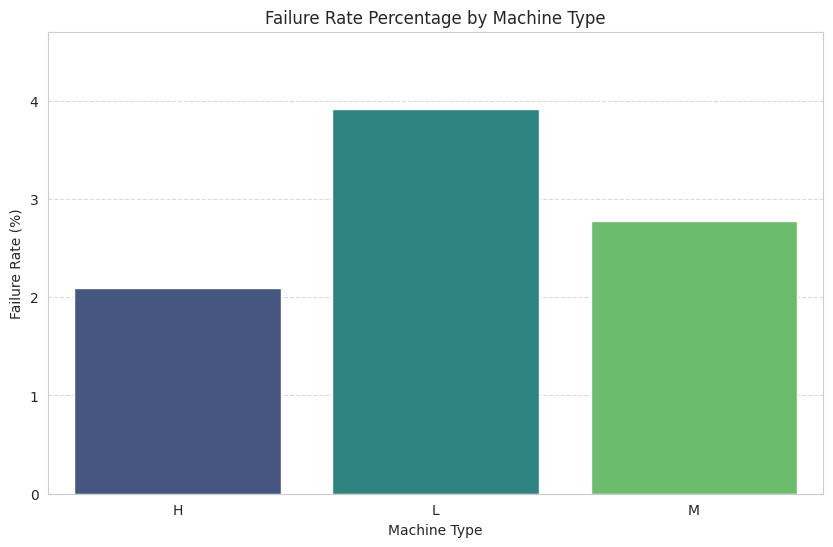

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x=failure_rate_by_type.index, y=failure_rate_by_type.values, palette='viridis', hue=failure_rate_by_type.index, legend=False)
plt.title('Failure Rate Percentage by Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Failure Rate (%)')
plt.ylim(0, failure_rate_by_type.max() * 1.2) # Set y-limit to slightly above max for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Please review the listed datasets and let me know which one you'd like to use for our analysis, or if you'd like to try a different search query.

In [18]:
from kaggle.api.kaggle_api_extended import KaggleApi
from google.colab import userdata

# Configure Kaggle API with secrets
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

api = KaggleApi()
api.authenticate()